In [1]:
from astropy import units as u
from astropy import time
import astropy
import numpy as np

from poliastro import iod
from poliastro.bodies import Body,Mars, Earth, Venus, Jupiter, Saturn, Uranus, Neptune, Sun, Europa, Ganymede, Callisto, Io, Titan
from poliastro.ephem import Ephem
from poliastro.maneuver import Maneuver
from poliastro.twobody import Orbit
from poliastro.util import time_range
from poliastro.frames import Planes
from poliastro.frames.fixed import JupiterFixed
from poliastro.frames.equatorial import JupiterICRS
from astroquery.jplhorizons import Horizons
from copy import deepcopy

from scipy import ndimage
from scipy.spatial.transform import Rotation as scipyRot

from poliastro.plotting import OrbitPlotter3D, StaticOrbitPlotter
import math
import matplotlib.pyplot as plt
# More info: https://plotly.com/python/renderers/
import plotly.io as pio
from poliastro.util import norm, time_range
pio.renderers.default = "plotly_mimetype+notebook_connected"
import weakref
from astropy.coordinates import solar_system_ephemeris
from collections.abc import Mapping
# from libs.poliastro_util_extra import  match_astro_query_num,  get_single_burn_elliptical_hohmann ,match_orbit_plane


solar_system_ephemeris.set("jpl")

<ScienceState solar_system_ephemeris: 'jpl'>

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"



1.0921796500364955 rad
-1.0990437978993617 rad


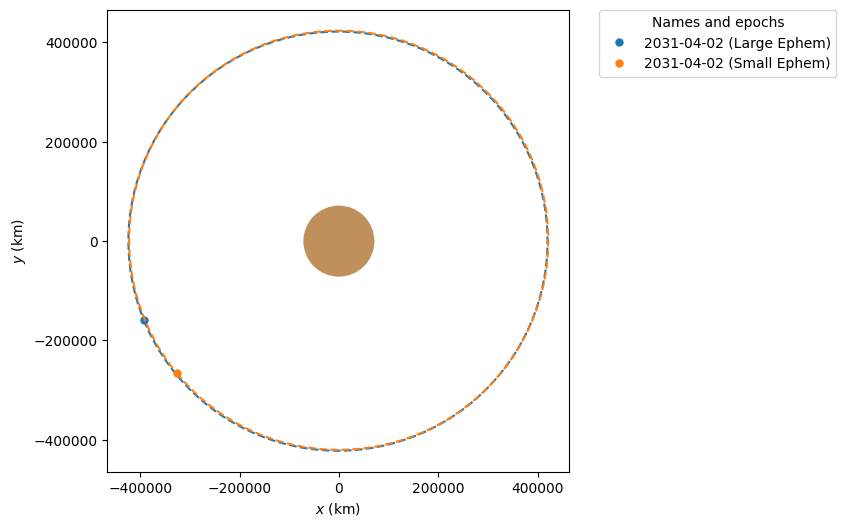

In [5]:


sim_start_date = time.Time("2031-01-01 00:00", scale="utc").tdb
sim_test_date_1 = time.Time("2031-04-02 00:00", scale="utc").tdb
sim_test_date_2= time.Time("2031-05-01 00:00", scale="utc").tdb

sim_end_date = time.Time("2032-07-01 00:00", scale="utc").tdb

epochs_large = time_range(sim_start_date, end=sim_end_date)
epochs_small = time_range(sim_start_date, end=sim_test_date_1)

io_ephem = Ephem.from_horizons(501,epochs= epochs_large, attractor= Jupiter, plane=Planes.EARTH_ECLIPTIC)#Io is 501
io_ephem_small = Ephem.from_horizons(501,epochs= epochs_small, attractor= Jupiter, plane=Planes.EARTH_ECLIPTIC)#Io is 501


io_test_orbit = Orbit.from_ephem(Jupiter,io_ephem,sim_start_date)
io_test_orbit_small = Orbit.from_ephem(Jupiter,io_ephem_small,sim_test_date_1)

print(io_test_orbit.nu)
print(io_test_orbit_small.nu)


io_test_orb_live_small=io_test_orbit_small.propagate(sim_test_date_1)
io_test_orb_live_large=io_test_orbit.propagate(sim_test_date_1)
plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
plotter.plot(io_test_orb_live_large, label="Large Ephem")
plotter.plot(io_test_orb_live_small, label="Small Ephem")